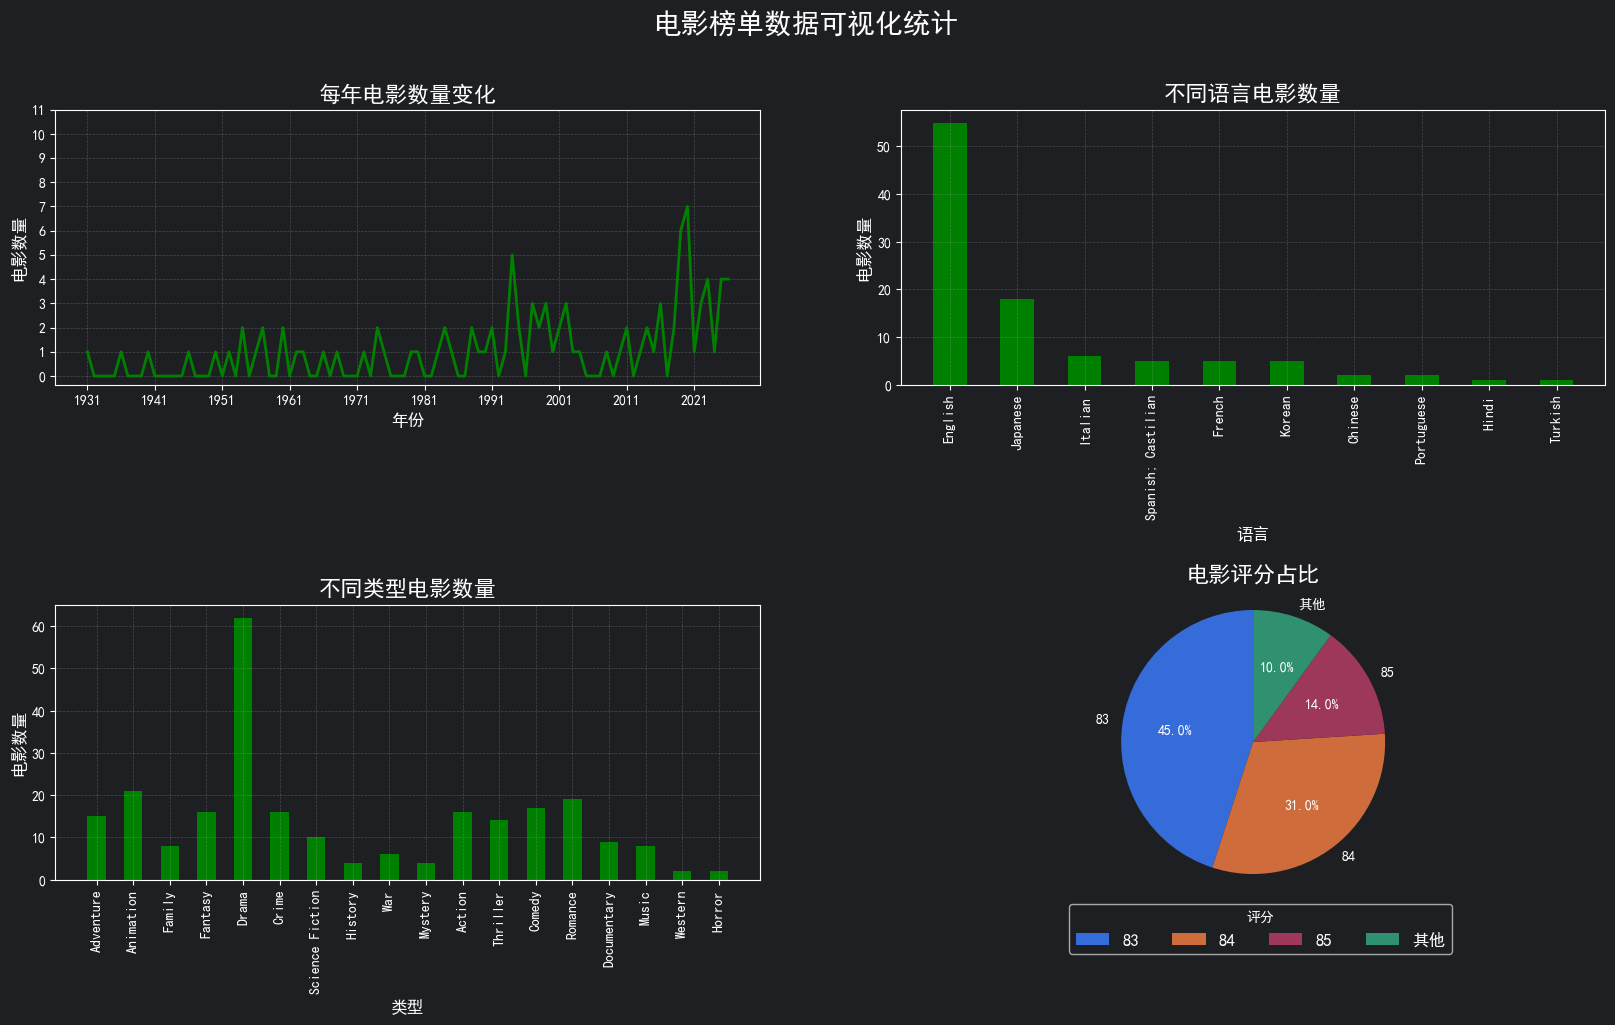

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.min_rows', 20)
# 显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

# 创建子图
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
fig.suptitle('电影榜单数据可视化统计', fontsize=20)
fig.subplots_adjust(hspace=0.8)  # 调整子图间距

# 获取子图
ax1: plt.Axes = axes[0, 0]
ax2: plt.Axes = axes[0, 1]
ax3: plt.Axes = axes[1, 0]
ax4: plt.Axes = axes[1, 1]

# 读取加载数据
data = pd.read_csv('data/movies_list.csv', usecols=['电影名称', '上映年份', '上映时间', '电影标签', '播放时长', '评分', '语言'], dtype={
    '上映年份': 'Int64',
})
"""
----统计每年电影数量的折线图变化----
"""
year_counts = data.groupby('上映年份')['上映年份'].count()  # 获取每年电影数量
min_year = year_counts.index.min()
max_year = year_counts.index.max()
x = [i for i in range(min_year, max_year + 1)]  # 创建X轴数据
y = [year_counts.get(i, 0) for i in x]  # 创建Y轴数据

ax1.plot(x, y, linewidth=2, color='green')  # 绘制折线图
ax1.set_title('每年电影数量变化', fontsize=16, fontweight='bold')
ax1.set_xlabel('年份', fontsize=12)
ax1.set_ylabel('电影数量', fontsize=12)
ax1.set_xticks(x[::10])  # 设置X刻度
ax1.set_yticks([i for i in range(0, 12, 1)])  # 设置Y刻度
ax1.grid(True, linestyle='--', alpha=0.3)

"""
----统计不同语言的电影数量 柱状图----
"""
data_lang = data.groupby('语言')['语言'].count().sort_values(ascending=False)  # 获取不同语言电影数量
x_lang = data_lang.index
y_lang = data_lang.values
ax2.bar(x_lang, y_lang, width=0.5, color='green')  # 绘制柱状图
ax2.set_title('不同语言电影数量', fontsize=16, fontweight='bold')
ax2.set_xlabel('语言', fontsize=12)
ax2.set_ylabel('电影数量', fontsize=12)
ax2.set_xticks(x_lang)
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.tick_params(axis='x', rotation=90)  # 旋转X轴标签

"""
----统计不同标签的电影数量 柱状图----
"""
type_count = {}  # 创建字典  ---  {'Drama': 2}
for tags in data['电影标签'].str.split(','):
    for tag in tags:
        type_count[tag] = type_count.get(tag, 0) + 1

x_types = list(type_count.keys())
y_types = list(type_count.values())

ax3.bar(x_types, y_types, width=0.5, color='green')  # 绘制柱状图
ax3.set_title('不同类型电影数量', fontsize=16, fontweight='bold')
ax3.set_xlabel('类型', fontsize=12)
ax3.set_ylabel('电影数量', fontsize=12)
ax3.set_xticks(x_types)
ax3.grid(True, linestyle='--', alpha=0.3)
ax3.tick_params(axis='x', rotation=90)  # 旋转X轴标签

"""
---- 统计各个评分的电影占比 饼状图----
"""
score_count = data.groupby('评分')['评分'].count()
total_scores = score_count.sum()
large_scores = score_count.loc[score_count >= total_scores * 0.05]
small_scores = score_count.loc[score_count < total_scores * 0.05]

if small_scores.sum() > 0:
    large_scores['其他'] = small_scores.sum()

ax4.pie(large_scores, labels=large_scores.index, autopct='%1.1f%%', startangle=90, radius=1.2)
ax4.set_title('电影评分占比', fontsize=16, fontweight='bold', y=1.05)
ax4.legend(bbox_to_anchor=(-0.2, -0.3), loc='lower left', fontsize=12, title='评分', ncol=4)

"""
保存图片,显示画布
"""
plt.savefig('data/movies_list.png')
plt.show()